<a href="https://colab.research.google.com/github/hiltonsnascimento-cpu/projeto-streamlit/blob/main/Vendas_Techstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from  google.colab import files
uploaded = files.upload()

Saving vendas_techstore.csv to vendas_techstore (2).csv


Total vendido por vendedor:
vendedor
Juliana     10935.0
Marcos      10758.0
Vinícius     9852.0
Rafael       8450.0
Patrícia     7925.0
Name: valor, dtype: float64

Total vendido por região:
regiao
Sudeste         18713.0
Nordeste        13385.0
Sul              8505.0
Norte            5475.0
Centro-Oeste     1842.0
Name: valor, dtype: float64
Faturamento total: R$ 47,920.00
Ticket médio: R$ 1,597.33

Ticket médio por vendedor: 
vendedor
Juliana     1822.500000
Vinícius    1642.000000
Patrícia    1585.000000
Marcos      1536.857143
Rafael      1408.333333
Name: valor, dtype: float64

Faturamento por mês:
data
2026-01    25230.0
2026-02    22690.0
Freq: M, Name: valor, dtype: float64


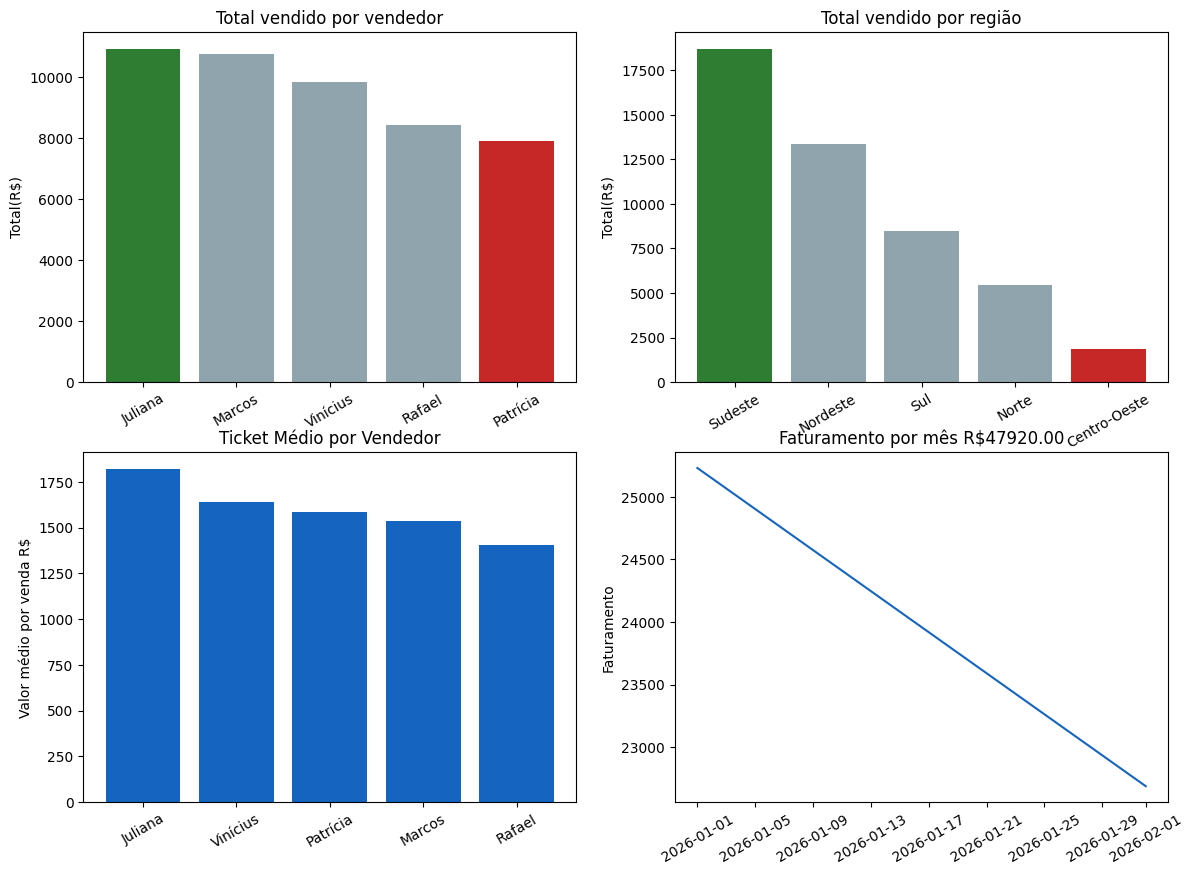

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("vendas_techstore.csv")
df.head()

df.shape
df.dtypes

df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month
df.head()

vendas_vendedor = df.groupby("vendedor")["valor"].sum().sort_values(ascending=False)
print("Total vendido por vendedor:")
print(vendas_vendedor)

vendas_regiao = df.groupby("regiao")["valor"].sum().sort_values(ascending=False)
print("\nTotal vendido por região:")
print(vendas_regiao)

faturamento_total = df["valor"].sum()
ticket_medio = df["valor"].mean()
print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Ticket médio: R$ {ticket_medio:,.2f}")

ticket_por_vendedor = df.groupby("vendedor")["valor"].mean().sort_values(ascending=False)
print("\nTicket médio por vendedor: ")
print(ticket_por_vendedor)

faturamento_mes = df.groupby(df["data"].dt.to_period("M"))["valor"].sum()
print("\nFaturamento por mês:")
print(faturamento_mes)

total_por_vendedor = vendas_vendedor
melhor_vendedor = total_por_vendedor.index[0]
pior_vendedor = total_por_vendedor.index[-1]

total_por_regiao = vendas_regiao
melhor_regiao = total_por_regiao.index[0]
pior_regiao = total_por_regiao.index[-1]

media_por_vendedor = ticket_por_vendedor
faturamento_por_mes = faturamento_mes

fig, ((ax1,ax2), (ax3,ax4)) = plt.subplots(2,2, figsize=(14,10))

##### Gráfico 1 total vendido por vendedor
cores_vendedor = [
    '#2E7D32' if v == melhor_vendedor else '#C62828' if v== pior_vendedor else '#90A4AE'
    for v in total_por_vendedor.index
]
ax1.bar(total_por_vendedor.index, total_por_vendedor.values,color = cores_vendedor)
ax1.set_title('Total vendido por vendedor')
ax1.set_ylabel('Total(R$)')
ax1.tick_params(axis = 'x', rotation = 30)

##### Gráfico 2 Total por região
cores_regiao = [
    '#2E7D32' if r == melhor_regiao else '#C62828' if r== pior_regiao else '#90A4AE'
    for r in total_por_regiao.index
]
ax2.bar(total_por_regiao.index, total_por_regiao.values,color = cores_regiao)
ax2.set_title('Total vendido por região')
ax2.set_ylabel('Total(R$)')
ax2.tick_params(axis = 'x', rotation = 30)

#### Gráfico 3 -- Ticket médio por vendedor
ax3.bar(media_por_vendedor.index, media_por_vendedor.values,color = "#1565C0")
ax3.set_title('Ticket Médio por Vendedor')
ax3.set_ylabel('Valor médio por venda R$')
ax3.tick_params(axis = 'x', rotation = 30)

#### Gráfico 4 --- Faturamento total por mês
ax4.plot(faturamento_por_mes.index.to_timestamp(), faturamento_por_mes.values,color = "#1565C0")
ax4.set_title(f'Faturamento por mês R${faturamento_total:.2f}')
ax4.set_ylabel('Faturamento')
ax4.tick_params(axis = 'x', rotation = 30)